Shape: (201, 201, 4)
Min: 0.0
Max: 297.76


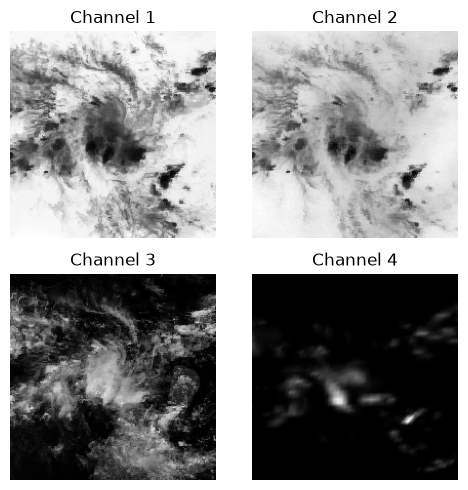

In [13]:
import h5py
import matplotlib.pyplot as plt

# h5_path = "data/tcir_io.h5"
h5_path = "../data/tcir_io.h5"

# Pick an image index
index = 1476

with h5py.File(h5_path, "r") as f:
    image = f["matrix"][index]

print("Shape:", image.shape)
print("Min:", image.min())
print("Max:", image.max())

# Show the 4 channels
fig, axes = plt.subplots(2, 2, figsize=(5,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(image[:, :, i], cmap="gray")
    ax.set_title(f"Channel {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../reports/tcir_sample_channels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Your notebook is inside ~/CycloneAI/notebooks/
h5_path = "../data/tcir_io.h5"
output_path = "../reports/cyclone_input_channel1.png"

# Indian Ocean sample
index = 1472

with h5py.File(h5_path, "r") as f:
    image = f["matrix"][index]
    channel1 = image[:, :, 0].astype(np.float32)

# Improve contrast
low, high = np.percentile(channel1, [2, 98])
channel1 = np.clip(
    (channel1 - low) / (high - low),
    0,
    1
)

# Create clean image
fig = plt.figure(figsize=(7, 7))
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(
    channel1,
    cmap="gray",
    interpolation="bilinear"
)

ax.axis("off")

# Save
Path("../reports").mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_path,
    dpi=400,
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

print("Saved:", output_path)

Saved: ../reports/cyclone_input_channel1.png
